# Landweber iteration and discrepancy principle
In this lab, you should solve a three-dimensional tomography problem with the Landweber method. Have a look at the lecture slides to see how this method should work. 

* Start by initializing an appropriate discretized space, in this case a three-dimensional function space centered at (0,0,0), starting with $32 \times 32 \times 32$ resolution for testing. Pass ``dtype='float32'``, which the ASTRA backend requires in ODL 1.0.

* Create a three-dimensional [Shepp–Logan phantom](https://odl.readthedocs.io/generated/odl.core.phantom.transmission.shepp_logan.html) in the space by calling ``odl.phantom.transmission.shepp_logan(Space, modified=True)`` (noting that the modified phantom has much higher contrast than the unmodified version). Make sure that the phantom is centered at the origin with the ``show`` method (this only shows a slice of this 3D function). 

* Form the forward operator for the ray transform with a [cone beam geometry](https://odl.readthedocs.io/generated/odl.applications.tomo.geometry.conebeam.cone_beam_geometry.html) (you can call ``odl.applications.tomo.cone_beam_geometry``) with a small number $(\sim 10)$ of angles, otherwise you will not see the effects of semi-convergence. 

* Apply the forward operator to the phantom to obtain the sinogram, then add some noise to it (note that the sinogram lives in ``Operator.range``).

* You can obtain the norm of a vector with its [norm method](https://odl.readthedocs.io/generated/odl.DiscretizedSpaceElement.norm.html). For the discrepancy of the Landweber method, you will also need the absolute noise level $\| g - g_{\mathrm{noisy}}\|$ of the sinogram $g$ (in real applications you must estimate the noise level somehow).

* You can obtain an estimate of the largest singular value of the forward operator with its [norm method](https://odl.readthedocs.io/generated/odl.Operator.norm.html). Note that this is operator norm, which may need to be estimated (by odl) if the relevant space does not have an analytic method for calculating it.

* The adjoint of the forward operator is given by ``Operator.adjoint``.

* Implement the Landweber method as a function and employ $\sim 200$ iterations to obtain a solution for the noisy sinogram, starting with the [zero vector](https://odl.readthedocs.io/generated/odl.DiscretizedSpace.zero.html) as your initial guess.

* Log the pertinent norms between iterations and check when the discrepancy criterion is satisfied (but do not stop the iteration).

* Plot the relative error of your reconstructions against the number of iterations and check when the discrepancy criterion would have stopped the iterations: what would it have given you?

* Use the ``show`` method to inspect your best reconstruction and compare it with the original phantom. Since this is a 3D function, you should also try to show different slices and perspectives (check the documentation for details).

In [2]:
import odl
import numpy as np
import matplotlib.pyplot as plt

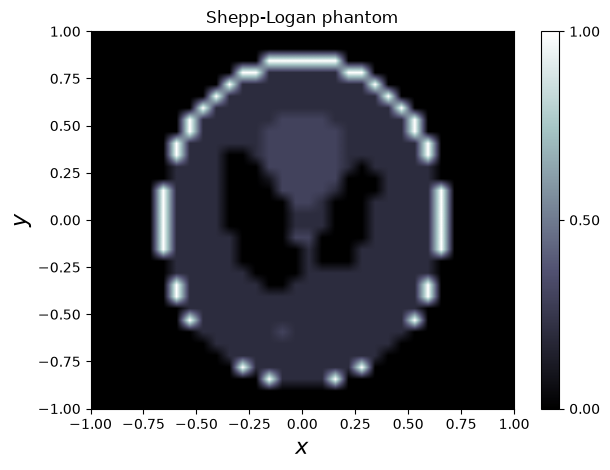

<Figure size 640x480 with 0 Axes>

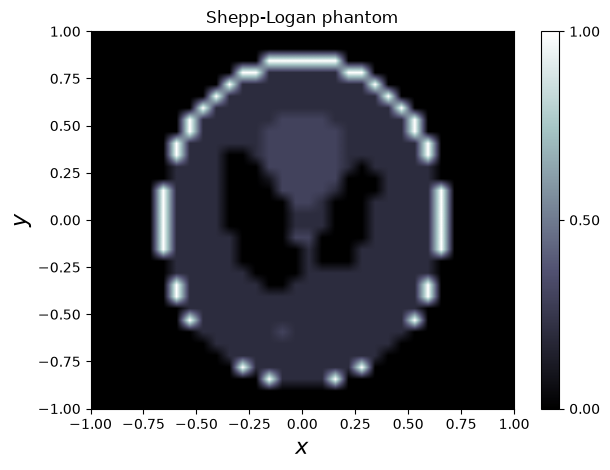

In [3]:
space = odl.uniform_discr((-1, -1, -1), (1, 1, 1), (32, 32, 32), dtype='float32')

shepp_logan = odl.phantom.transmission.shepp_logan(space, modified=True)
shepp_logan.show(title='Shepp-Logan phantom')

In [4]:
cone_beam_geo = odl.applications.tomo.cone_beam_geometry(space, src_radius=2.0, det_radius=1.5, num_angles=10)
ray_transform = odl.applications.tomo.RayTransform(space, cone_beam_geo)
ray_transform_elements = ray_transform(shepp_logan)
noisy_elements = ray_transform_elements + odl.phantom.white_noise(ray_transform.range, stddev=0.25)
noisy_elements.show(title='Noisy cone beam data')

ValueError: `impl` AstraCpuImpl only works for 2d